#Visualização de dados com Autoencoders (AEs)

Disciplina: Métodos e Modelos Avançados em Ciência de Dados

Especialização em Ciência de Dados - Universidade Tecnologica Federal do Paraná

Aula 05: AEs

Linguagem de Programação: **Python**

by: Rafael G. Mantovani

---

In [ ]:
# requirements
# pip install numpy matplotlib scikit-learn umap-learn

In [4]:
# manipulação de números em ponto flutuante
import numpy as np

# plots
import matplotlib.pyplot as plt

# carregar datasets via OpenML
from sklearn.datasets import fetch_openml

# preprocessamento do dataset
from sklearn.preprocessing import MinMaxScaler

# dividir os dados em treino e teste

from sklearn.model_selection import train_test_split

# estruturas básicas para definição de modelos de DL
from tensorflow import keras
from tensorflow.keras import layers, models

# visualização de dados via PCA e UMAP
from sklearn.decomposition import PCA
import umap

In [6]:
# definir um seed para reprodução dos experimentos
np.random.seed(42)
keras.utils.set_random_seed(42)

In [7]:
# 1. Carregando o dataset (MNIST) do repositório online OpenML
print("Carregando dataset...")
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X.astype("float32")

Carregando dataset...


In [8]:
# Normalizando cada valor (pixels) originalmente no intervalo [0-255] p o intervalo [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Dividir os dados em conjuntos de treino e teste (proporção 80|20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [9]:
# Definir o tamanho das nossas representações codificadas
# (codings, ou representações latentes)
# 32 features extraídas de 784 valores
encoding_dim = 2

# numero de epocas para os experimentos
exp_epochs = 30

# dimensão dos dados de entrada
input_dim = X_train.shape[1]  # 784 features

In [20]:
encoder = models.Sequential(name = "Encoder",
    layers = [
        layers.Dense(128, activation='relu', input_shape = [input_dim], name = "encoder_hidden_layer_1"),
        layers.Dense(64, activation='relu', name = "encoder_hidden_layer_2"),
        layers.Dense(encoding_dim, activation='linear', name = "encoder_output_layer")
])

# imprimindo o modelo criado
encoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_hidden_layer_1 (Dense)  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_hidden_layer_2 (Dense)  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output_layer (Dense)    │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
decoder = models.Sequential(name = "Decoder",
    layers = [
        layers.Dense(64, activation='relu', input_shape = [encoding_dim], name = "decoder_hidden_layer_1"),
        layers.Dense(128, activation='relu', name = "decoder_hidden_layer_2"),
        layers.Dense(input_dim, activation='sigmoid', name = "decoder_output_layer")
])

# imprimindo o modelo criado
decoder.summary()

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_hidden_layer_1 (Dense)  │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_hidden_layer_2 (Dense)  │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output_layer (Dense)    │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,648 (428.31 KB)

 Trainable params: 109,648 (428.31 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Criar o autoencoder combinando enconder + decoder
autoencoder = models.Sequential(
    name = "autoencoder",
    layers = [encoder, decoder]
)

# imprimindo o modelo
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder (Sequential)            │ (None, 2)              │       108,866 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Sequential)            │ (None, 784)            │       109,648 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,514 (853.57 KB)

 Trainable params: 218,514 (853.57 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
autoencoder.compile(optimizer='adam', loss='mse')

In [25]:
# 3. Compilar & Treinar o AEs
history = autoencoder.fit(
    X_train, X_train,
    epochs=exp_epochs,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1026 - val_loss: 0.0570
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0555 - val_loss: 0.0516
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0512 - val_loss: 0.0485
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0482 - val_loss: 0.0464
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0463 - val_loss: 0.0451
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0451 - val_loss: 0.0442
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0442 - val_loss: 0.0434
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0435 - val_loss: 0.0429
Epoch 9/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0429 - val_loss: 0.0424
Epoch 10/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0424 - val_loss: 0.0419
Epoch 11/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0419 - val_loss: 0.0417
Epoch 12/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 

In [26]:
# 4. Extrair as feature abstratas do espaço latente de 2 dimensões

# realizar a codificação do conjunto de teste
X_encoded = encoder.predict(X_test)

# reconstruir as entradas por meio dos codings
decoded_imgs = decoder.predict(X_encoded)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


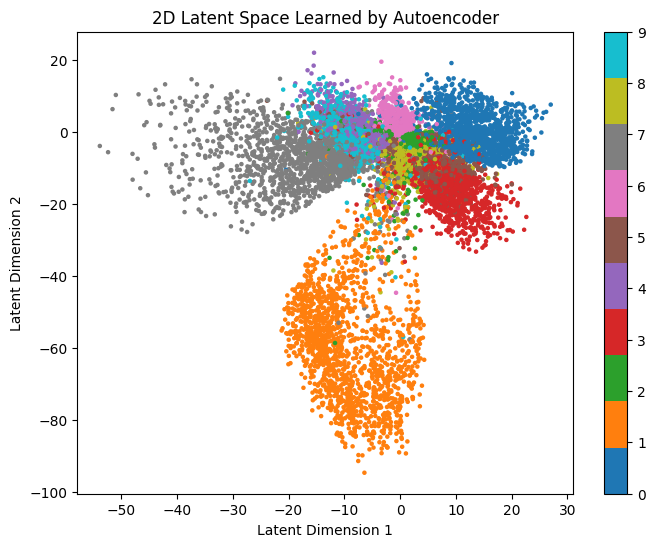

In [28]:
# 5. Visualizar o espaço de codificação
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_encoded[:, 0], X_encoded[:, 1], c=y_test.astype(int), cmap='tab10', s=5)
plt.colorbar(scatter)
plt.title("2D Latent Space Learned by Autoencoder")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.show()


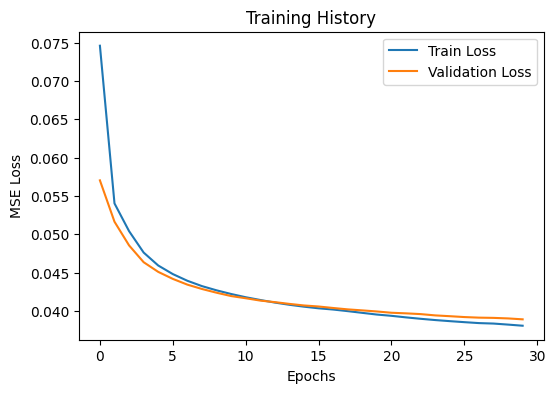

In [30]:
# 6. Plotando as curvas de aprendizado (treino e validação)
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training History")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


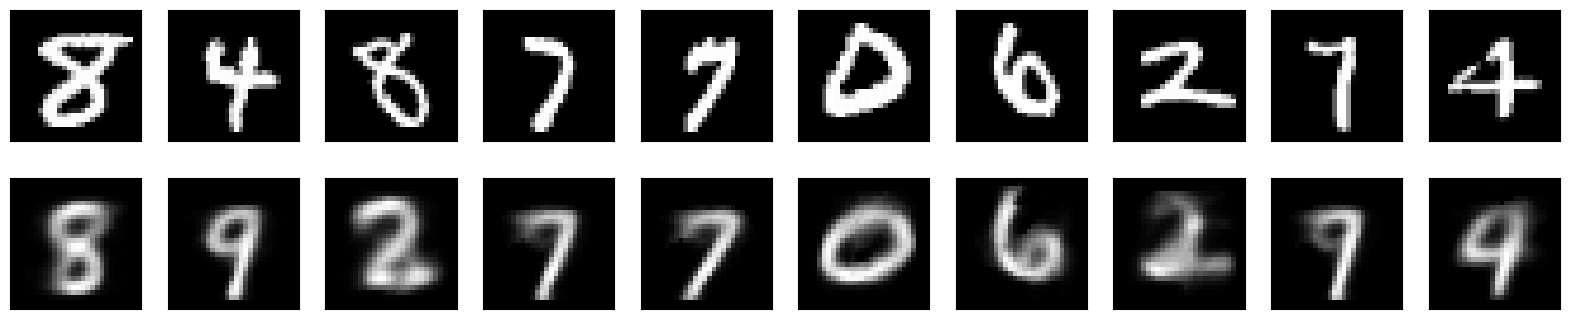

In [29]:
# Verificar as reconstruções (outputs)
# Vamos visualizar as reconstruções com base nas imagens originais
# linha 1 - imagens originais
# linha 2 - imagens reconstruidas pelo AE simples

n = 10  #numero de imagens que queremos ver

plt.figure(figsize=(20, 4))
for i in range(n):

    # imagens originais
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # imagens reconstruidas
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Applying PCA...


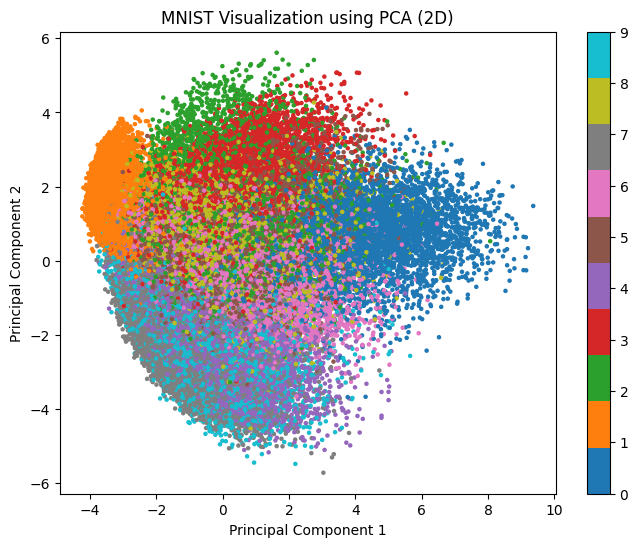

In [31]:
# 7. Visualizando os dados por meio de PCA (Análise de Componentes Principais)
print("Applying PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train.astype(int), cmap='tab10', s=5)
plt.colorbar(scatter)
plt.title("MNIST Visualization using PCA (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Applying UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


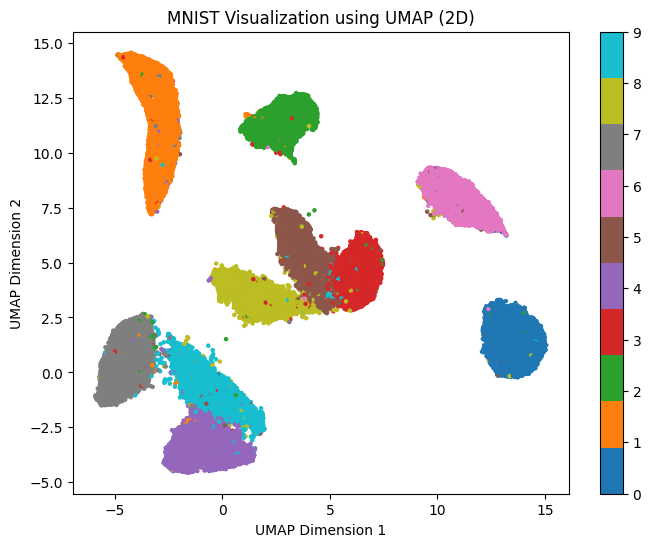

In [ ]:
# UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction
# 3. Visualizando os dados via UMAP
print("Applying UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_umap = reducer.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_train.astype(int), cmap='tab10', s=5)
plt.colorbar(scatter)
plt.title("MNIST Visualization using UMAP (2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()